# Assignment 3: Predicting Hyderabad Rainfall Using NEX-GDDP-CMIP6 Data

**Model:** ACCESS-CM2  
**Scenario:** SSP2-4.5 (moderate emissions)  
**Historical Period:** 1984–2014  
**Future Period:** 2015–2035  
**Target Area:** Himayat Sagar Catchment (Lat 17.21–17.35, Lon 78.27–78.39)  

**Variables:**
| Variable | Description | Raw Unit | Converted Unit |
|----------|-------------|----------|----------------|
| hurs | Near-Surface Relative Humidity | % | % |
| tas | Daily Near-Surface Air Temperature | K | °C |
| rsds | Shortwave Radiation | W m⁻² | W m⁻² | 
| sfcWind | Daily Mean Near-Surface Wind Speed | m/s | m/s |
| pr | Precipitation | kg m⁻² s⁻¹ | mm/day |

In [1]:
# Common imports used throughout the notebook
import os
import requests
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nex_gddp
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Constants
BBOX = (78.2315, 17.1489, 78.4857, 17.3591)
DATA_DIR = "./data"
VARIABLES = ["hurs", "tas", "rsds", "sfcWind", "pr"]
HIST_YEARS = list(range(1984, 2015))
FUTURE_YEARS = list(range(2015, 2036))
MODEL = "ACCESS-CM2"
SCENARIO = "ssp245"

# Column name mapping for NEX-GDDP
UNIT_MAP = {
    "hurs": "Relative Humidity (%)",
    "tas": "Average Temperature (°C)",
    "rsds": "Shortwave Radiation (W/m^2)",
    "sfcWind": "Wind Speed (m/s)",
    "pr": "Precipitation (mm/day)"
}

def load_nc_var(data_dir, model, scenario, var):
    """Load a single variable from NetCDF files and return a spatially-averaged time series."""
    var_dir = Path(data_dir) / model / scenario / var
    files = sorted(var_dir.glob("*.nc"))
    if not files:
        print(f"  ⚠ No files found for {var} in {scenario}.")
        return None
    ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
    df = ds[var].to_dataframe().reset_index()
    df_time = df.groupby('time')[var].mean().reset_index()
    return df_time

def load_and_merge(data_dir, model, scenario, variables):
    """Load multiple variables and merge into one DataFrame."""
    dfs = []
    for var in variables:
        df_var = load_nc_var(data_dir, model, scenario, var)
        if df_var is not None and not df_var.empty:
            dfs.append(df_var)
    if not dfs:
        return pd.DataFrame()
    merged = dfs[0]
    for i in range(1, len(dfs)):
        merged = merged.merge(dfs[i], on='time', how='inner')
    merged['time'] = pd.to_datetime([str(t) for t in merged['time']])
    merged.dropna(inplace=True)
    return merged

def convert_units(df):
    """Convert raw CMIP6 units to human-readable units in-place."""
    for col in ['tas']:
        if col in df.columns:
            df[col] = df[col] - 273.15
    if 'pr' in df.columns:
        df['pr'] = df['pr'] * 86400
    df.rename(columns=UNIT_MAP, inplace=True)
    return df

def cap_outliers_hybrid(df, columns):
    """
    Replace outliers:
    - Precipitation: Cap at 500 mm/day (and minimum 0).
    - Other variables: Cap at max/min actual values within 3-sigma bounds.
    """
    df_capped = df.copy()
    for col in columns:
        if col == "Precipitation (mm/day)":
            df_capped.loc[df_capped[col] > 100, col] = 100
            df_capped.loc[df_capped[col] < 0, col] = 0
        else:
            mean_val = df_capped[col].mean()
            std_val = df_capped[col].std()
            lower_bound = mean_val - (3 * std_val)
            upper_bound = mean_val + (3 * std_val)
            
            valid_data = df_capped[(df_capped[col] >= lower_bound) & (df_capped[col] <= upper_bound)][col]
            if not valid_data.empty:
                actual_min = valid_data.min()
                actual_max = valid_data.max()
                df_capped.loc[df_capped[col] < lower_bound, col] = actual_min
                df_capped.loc[df_capped[col] > upper_bound, col] = actual_max
    return df_capped

print("✓ Setup complete.")

/home/ashurudra09/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✓ Setup complete.


---
## Step 1: Download Historical Data (1984–2014)

In [2]:
# 2)
print(f"Fetching historical data from NASA POWER API ({HIST_YEARS[0]}-{HIST_YEARS[-1]})...")

# Calculate centroid of the BBOX
lat = (BBOX[1] + BBOX[3]) / 2.0
lon = (BBOX[0] + BBOX[2]) / 2.0

base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
chunks = [HIST_YEARS[i:i + 10] for i in range(0, len(HIST_YEARS), 10)]
dfs = []

for chunk in chunks:
    start_date = f"{chunk[0]}0101"
    end_date = f"{chunk[-1]}1231"
    
    params = {
        "parameters": "T2M,RH2M,ALLSKY_SFC_SW_DWN,WS2M,PRECTOTCORR",
        "community": "AG", 
        "longitude": lon,
        "latitude": lat,
        "start": start_date,
        "end": end_date,
        "format": "JSON"
    }
    
    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
        df_chunk = pd.DataFrame(data['properties']['parameter'])
        dfs.append(df_chunk)
    else:
        print(f"⚠ Failed to fetch chunk {chunk[0]}-{chunk[-1]}: {response.status_code}")

hist_df = pd.concat(dfs)
hist_df.index = pd.to_datetime(hist_df.index, format='%Y%m%d')
hist_df.index.name = 'time'
hist_df = hist_df.reset_index()

hist_df.replace(-999.0, np.nan, inplace=True)
hist_df.dropna(inplace=True)

# Convert Units
hist_df['ALLSKY_SFC_SW_DWN'] = hist_df['ALLSKY_SFC_SW_DWN'] * 11.57407

power_map = {
    "RH2M": "Relative Humidity (%)",
    "T2M": "Average Temperature (°C)",
    "ALLSKY_SFC_SW_DWN": "Shortwave Radiation (W/m^2)",
    "WS2M": "Wind Speed (m/s)", 
    "PRECTOTCORR": "Precipitation (mm/day)"
}
hist_df.rename(columns=power_map, inplace=True)

# Outliers
climate_cols = list(power_map.values())
hist_df = cap_outliers_hybrid(hist_df, climate_cols)

# ---- ADVANCED FEATURE ENGINEERING ----
hist_df = hist_df.sort_values('time').reset_index(drop=True)

# 1. Cyclical Time Features (Seasonality)
hist_df['DayOfYear'] = hist_df['time'].dt.dayofyear
hist_df['Sin_DOY'] = np.sin(2 * np.pi * hist_df['DayOfYear'] / 365.25)
hist_df['Cos_DOY'] = np.cos(2 * np.pi * hist_df['DayOfYear'] / 365.25)

# 2. Lag Variables
hist_df['Rainfall Lag 1 (mm/day)'] = hist_df['Precipitation (mm/day)'].shift(1)
hist_df['Rainfall Lag 2 (mm/day)'] = hist_df['Precipitation (mm/day)'].shift(2)

# 3. Rolling Window Features (Synoptic Weather context)
# We shift(1) first so we don't leak TODAY'S weather into the prediction
hist_df['Rainfall_Roll_3'] = hist_df['Precipitation (mm/day)'].shift(1).rolling(window=3).mean()
hist_df['RH_Roll_3'] = hist_df['Relative Humidity (%)'].shift(1).rolling(window=3).mean()

hist_df.dropna(inplace=True) # Drop NaNs created by shifting/rolling

hist_df.to_csv("historical_data.csv", index=False)
print(f"✓ Saved historical_data.csv ({len(hist_df)} rows)")
hist_df.head()

Fetching historical data from NASA POWER API (1984-2014)...
✓ Saved historical_data.csv (11320 rows)


,time,Average Temperature (°C),Relative Humidity (%),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day),DayOfYear,Sin_DOY,Cos_DOY,Rainfall Lag 1 (mm/day),Rainfall Lag 2 (mm/day),Rainfall_Roll_3,RH_Roll_3
3,1984-01-04,21.75,71.95,170.370310,2.71,0.01,4,0.068755,0.997634,0.34,0.07,0.136667,75.070000
4,1984-01-05,22.30,69.85,189.699007,2.38,0.00,5,0.085906,0.996303,0.01,0.34,0.140000,74.600000
5,1984-01-06,22.58,71.62,170.717533,1.95,0.00,6,0.103031,0.994678,0.00,0.01,0.116667,71.966667
6,1984-01-07,22.12,72.19,163.657350,2.91,0.01,7,0.120126,0.992759,0.00,0.00,0.003333,71.140000
7,1984-01-08,21.15,75.16,159.606425,3.24,0.01,8,0.137185,0.990545,0.01,0.00,0.003333,71.220000


---
## Step 3: Download Future Data (2015–2035, SSP2-4.5)

In [3]:
print(f"Downloading future data for {VARIABLES} ({FUTURE_YEARS[0]}–{FUTURE_YEARS[-1]}), scenario: {SCENARIO}...")
nex_gddp.download(
    variables=VARIABLES,
    years=FUTURE_YEARS,
    models=MODEL,
    scenarios=SCENARIO,
    bbox=BBOX,
    output_dir=DATA_DIR,
    max_workers=1
)
print("✓ Future data download complete.")


=== ACCESS-CM2 / ssp245 / hurs ===
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2015.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2016.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2017.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2018.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2019.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2020.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2021.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2022.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2023.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2024.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2025.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2026.nc
  Saved data/ACCESS-CM2/ssp245/hurs/hurs_ACCESS-CM2_r1i1p1f1_gn_2027.nc
  Saved data/ACCESS-CM2/ssp2

---
## Step 4: Parse & Convert Future Data → `future_data.csv`

In [4]:
# 4)
print("Loading and merging future NetCDF files...")
future_df = load_and_merge(DATA_DIR, MODEL, SCENARIO, VARIABLES)

if future_df.empty:
    raise RuntimeError("No future data loaded. Ensure download step completed.")

future_df = convert_units(future_df)

# Outliers
climate_cols = list(UNIT_MAP.values())
future_df = cap_outliers_hybrid(future_df, climate_cols)

# ---- ADVANCED FEATURE ENGINEERING ----
future_df = future_df.sort_values('time').reset_index(drop=True)

# 1. Cyclical Time Features
future_df['DayOfYear'] = future_df['time'].dt.dayofyear
future_df['Sin_DOY'] = np.sin(2 * np.pi * future_df['DayOfYear'] / 365.25)
future_df['Cos_DOY'] = np.cos(2 * np.pi * future_df['DayOfYear'] / 365.25)

# 2. Lag Variables
future_df['Rainfall Lag 1 (mm/day)'] = future_df['Precipitation (mm/day)'].shift(1)
future_df['Rainfall Lag 2 (mm/day)'] = future_df['Precipitation (mm/day)'].shift(2)

# 3. Rolling Window Features
future_df['Rainfall_Roll_3'] = future_df['Precipitation (mm/day)'].shift(1).rolling(window=3).mean()
future_df['RH_Roll_3'] = future_df['Relative Humidity (%)'].shift(1).rolling(window=3).mean()

future_df.dropna(inplace=True)

future_df.to_csv("future_data.csv", index=False)
print(f"✓ Saved future_data.csv ({len(future_df)} rows)")
future_df.head()

Loading and merging future NetCDF files...


/tmp/ipykernel_10501/240120565.py:41: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
/tmp/ipykernel_10501/240120565.py:41: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files, use_cftime=True, engine='netcdf4')
/tmp/ipykernel_10501/240120565.py:41: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'd

✓ Saved future_data.csv (7667 rows)


,time,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day),DayOfYear,Sin_DOY,Cos_DOY,Rainfall Lag 1 (mm/day),Rainfall Lag 2 (mm/day),Rainfall_Roll_3,RH_Roll_3
3,2015-01-04 12:00:00,54.379150,20.847107,213.316498,3.569509,0.0,4,0.068755,0.997634,0.0,0.0,0.0,43.611899
4,2015-01-05 12:00:00,56.309361,20.634247,203.635986,3.278462,0.0,5,0.085906,0.996303,0.0,0.0,0.0,48.040395
5,2015-01-06 12:00:00,53.920662,20.783051,190.537613,3.281852,0.0,6,0.103031,0.994678,0.0,0.0,0.0,52.763874
6,2015-01-07 12:00:00,42.934597,19.920105,213.334045,3.246182,0.0,7,0.120126,0.992759,0.0,0.0,0.0,54.869724
7,2015-01-08 12:00:00,36.829090,19.237152,241.457458,2.841930,0.0,8,0.137185,0.990545,0.0,0.0,0.0,51.054873


---
## Step 5: Descriptive Statistics & Visualizations

In [5]:
# Reload from CSV to ensure consistency
hist_df = pd.read_csv("historical_data.csv")
hist_df['time'] = pd.to_datetime(hist_df['time'])
future_df = pd.read_csv("future_data.csv")
future_df['time'] = pd.to_datetime(future_df['time'])

plot_vars = list(UNIT_MAP.values())
os.makedirs("visualizations", exist_ok=True)

# ---- Descriptive Statistics ----
print("="*60)
print("   HISTORICAL DATA — Descriptive Statistics (1984–2014)")
print("="*60)
hist_stats = hist_df[plot_vars].describe()
display(hist_stats)

print("\n" + "="*60)
print("   FUTURE DATA — Descriptive Statistics (2015–2035, SSP2-4.5)")
print("="*60)
future_stats = future_df[plot_vars].describe()
display(future_stats)

hist_stats.to_csv("historical_descriptive_statistics.csv")
future_stats.to_csv("future_descriptive_statistics.csv")
print("\n✓ Statistics saved to CSV files.")

   HISTORICAL DATA — Descriptive Statistics (1984–2014)


,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day)
count,11320.000000,11320.000000,11320.000000,11320.000000,11320.000000
mean,58.949549,25.751528,227.708959,2.693773,2.298694
std,22.148946,4.202735,49.762728,1.200493,6.822879
min,5.490000,15.220000,77.546269,0.440000,0.000000
25%,39.235000,23.080000,200.433957,1.820000,0.000000
50%,63.245000,24.910000,229.050845,2.350000,0.010000
75%,78.810000,28.280000,264.698981,3.320000,1.100000
max,95.490000,37.600000,346.180434,6.340000,100.000000



   FUTURE DATA — Descriptive Statistics (2015–2035, SSP2-4.5)


,Relative Humidity (%),Average Temperature (°C),Shortwave Radiation (W/m^2),Wind Speed (m/s),Precipitation (mm/day)
count,7667.000000,7667.000000,7667.000000,7667.000000,7667.000000
mean,56.516477,27.416327,240.073120,2.653937,2.462102
std,23.888833,3.860306,39.451965,0.847163,6.718486
min,15.000881,16.118530,123.254580,0.516898,0.000000
25%,34.375907,24.581039,211.786640,2.030598,0.000000
50%,52.378754,27.031403,235.063550,2.557087,0.000000
75%,82.030918,29.973908,265.625735,3.214394,0.406151
max,96.119220,38.708313,355.853270,5.197568,64.466619



✓ Statistics saved to CSV files.


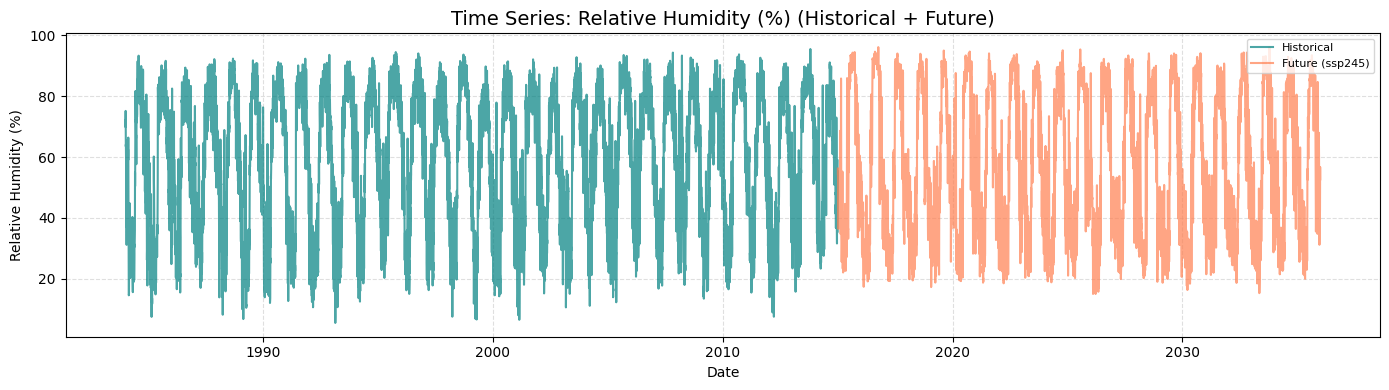

✓ Saved visualizations/timeseries_Relative_Humidity.png


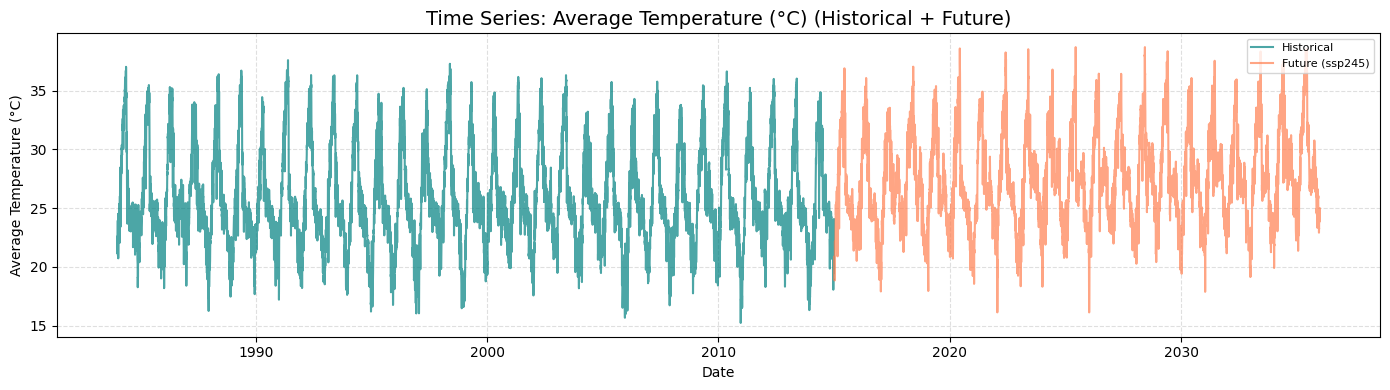

✓ Saved visualizations/timeseries_Average_Temperature_C.png


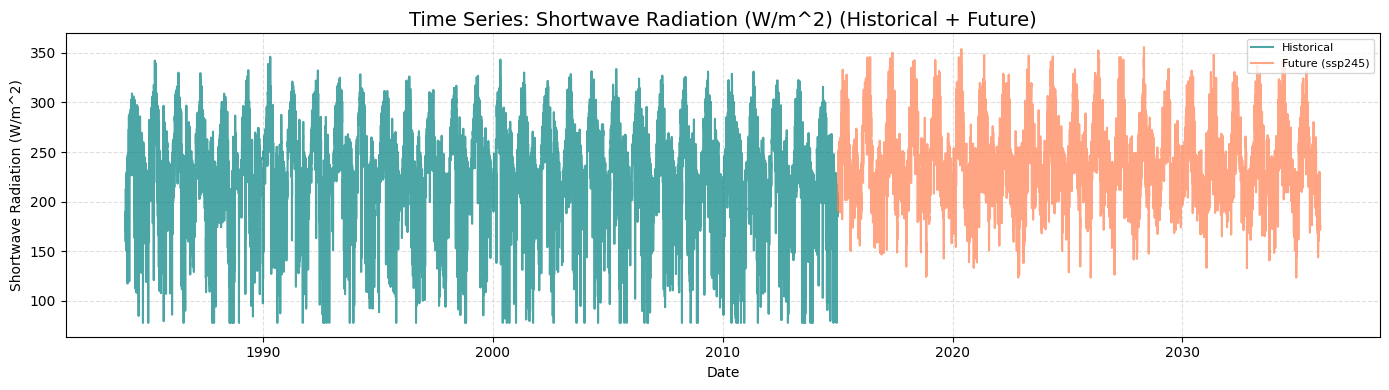

✓ Saved visualizations/timeseries_Shortwave_Radiation_W_m_2.png


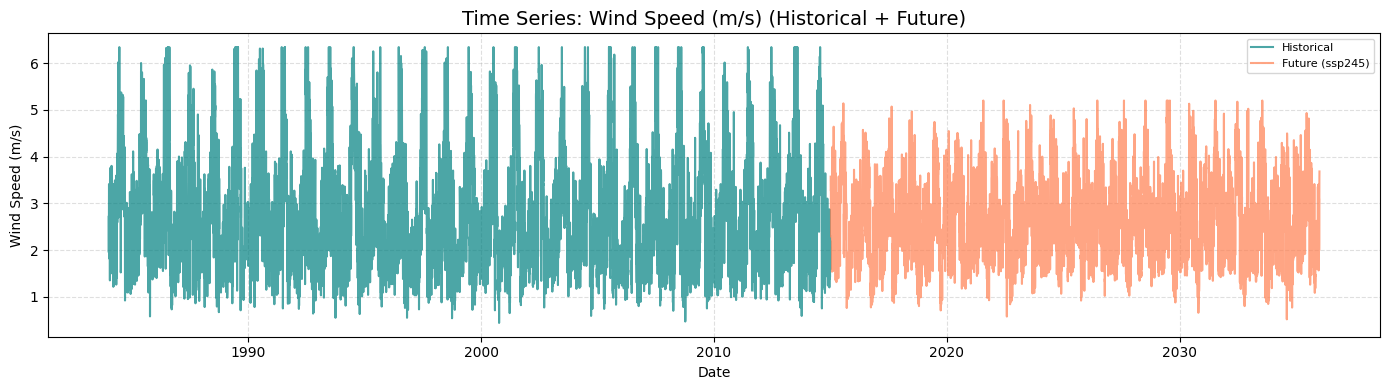

✓ Saved visualizations/timeseries_Wind_Speed_m_s.png


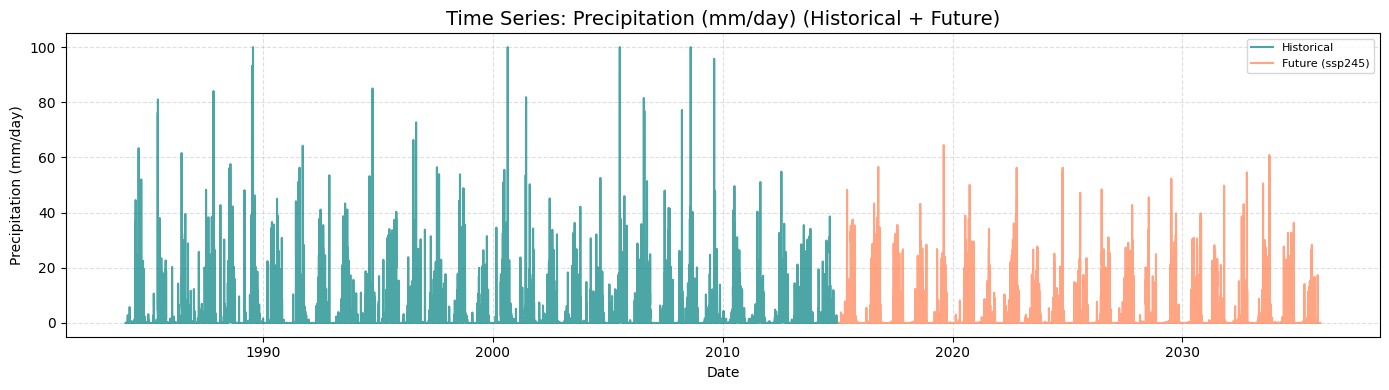

✓ Saved visualizations/timeseries_Precipitation_mm_day.png


In [6]:
import re

# ---- Time Series Plots ----
for var in plot_vars:
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Plot historical and future data
    ax.plot(hist_df['time'], hist_df[var], color='teal', alpha=0.7, label='Historical')
    ax.plot(future_df['time'], future_df[var], color='coral', alpha=0.7, label='Future (ssp245)')
    
    # Formatting
    ax.set_title(f"Time Series: {var} (Historical + Future)", fontsize=14)
    ax.set_ylabel(var, fontsize=10)
    ax.set_xlabel("Date", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    
    # Create a safe filename (e.g., "Average Temperature (°C)" -> "Average_Temperature_C")
    safe_var_name = re.sub(r'[^A-Za-z0-9]+', '_', var).strip('_')
    filename = f"visualizations/timeseries_{safe_var_name}.png"
    
    # Save and show
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"✓ Saved {filename}")

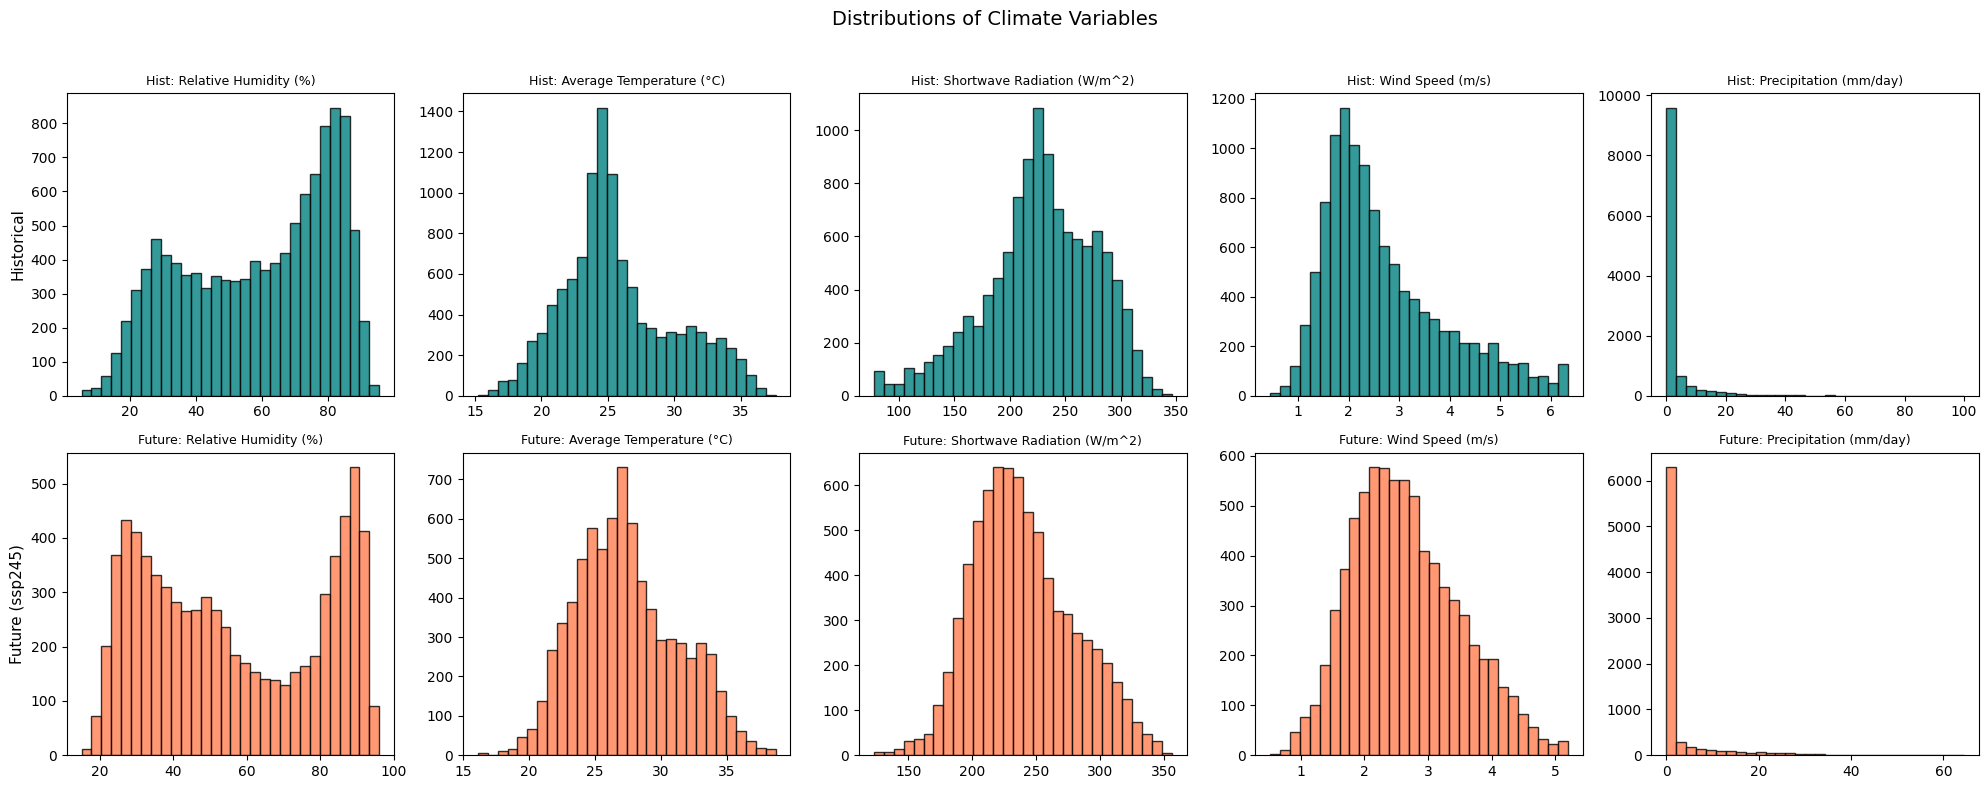

✓ Saved distributions.png


In [7]:
# ---- Distribution Histograms ----
fig, axes = plt.subplots(2, len(plot_vars), figsize=(4 * len(plot_vars), 8))
for j, var in enumerate(plot_vars):
    axes[0, j].hist(hist_df[var], bins=30, color='teal', edgecolor='black', alpha=0.8)
    axes[0, j].set_title(f"Hist: {var}", fontsize=9)
    axes[1, j].hist(future_df[var], bins=30, color='coral', edgecolor='black', alpha=0.8)
    axes[1, j].set_title(f"Future: {var}", fontsize=9)
axes[0, 0].set_ylabel("Historical", fontsize=11)
axes[1, 0].set_ylabel("Future (ssp245)", fontsize=11)
plt.suptitle("Distributions of Climate Variables", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("visualizations/distributions.png", dpi=200)
plt.show()
print("✓ Saved distributions.png")

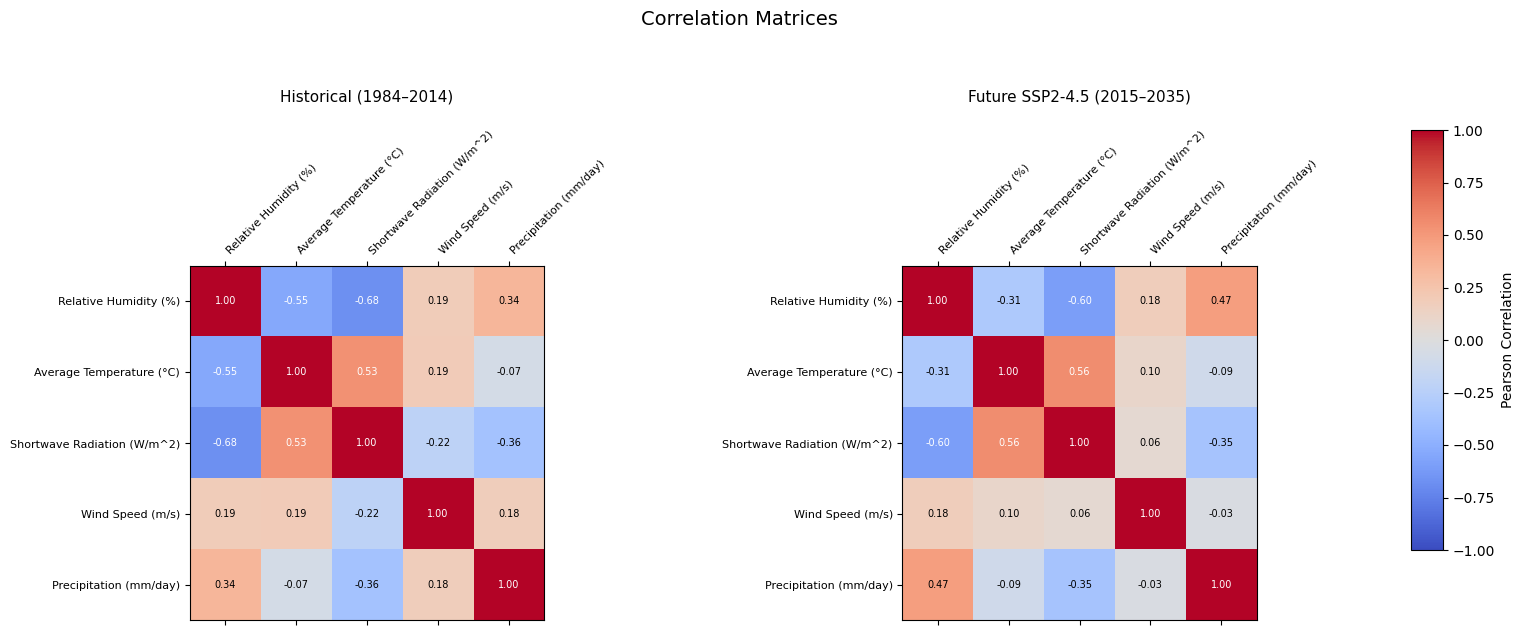

✓ Saved correlation_matrices.png


In [8]:
# ---- Correlation Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in zip(axes, [hist_df, future_df], ['Historical (1984–2014)', 'Future SSP2-4.5 (2015–2035)']):
    corr = df[plot_vars].corr()
    im = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(plot_vars)))
    ax.set_xticklabels(plot_vars, fontsize=8, rotation=45, ha='left')
    ax.set_yticks(range(len(plot_vars)))
    ax.set_yticklabels(plot_vars, fontsize=8)
    for (i, j), z in np.ndenumerate(corr.values):
        ax.text(j, i, f'{z:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(z) >= 0.5 else 'black')
    ax.set_title(title, pad=20, fontsize=11)

plt.suptitle("Correlation Matrices", fontsize=14, y=1.05)

# 1. Apply tight_layout, but reserve the right 10% of the figure (0.90) for the colorbar
plt.tight_layout(rect=[0, 0, 0.90, 1])

# 2. Create a dedicated axis for the colorbar to prevent any overlapping
# Coordinates: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

# 3. Draw the colorbar in the new dedicated axis
fig.colorbar(im, cax=cbar_ax, label='Pearson Correlation')

# bbox_inches='tight' ensures the suptitle and slanted labels aren't cut off
plt.savefig("visualizations/correlation_matrices.png", dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved correlation_matrices.png")

---
## Step 6: Build ML Models on Historical Data

**Target:** Precipitation (mm/day)  
**Predictors:** Relative Humidity, Average Temperature, Min Temperature, Max Temperature, Wind Speed  
**Models:** Linear Regression, Random Forest Regressor  
**Pre-processing:** StandardScaler normalization

In [9]:
# 9)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import QuantileTransformer

# Load historical CSV
hist_df = pd.read_csv("historical_data.csv")
hist_df['time'] = pd.to_datetime(hist_df['time'])
hist_df.dropna(inplace=True)

# ---- UPDATED PREDICTORS ----
predictors = [
    "Relative Humidity (%)",
    "Average Temperature (°C)",
    "Shortwave Radiation (W/m^2)",
    "Wind Speed (m/s)",
    "Rainfall Lag 1 (mm/day)",
    "Rainfall Lag 2 (mm/day)",
    "Sin_DOY", 
    "Cos_DOY",
    "Rainfall_Roll_3",
    "RH_Roll_3"
]
target = "Precipitation (mm/day)"

X = hist_df[predictors]
y = hist_df[target]

# Use QuantileTransformer instead of StandardScaler for highly skewed climate data
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=False
)

print("Tuning Random Forest hyperparameters... (this may take a minute or two)")

# Adjusted grid to prevent overfitting to noisy precipitation data
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 8], # Increased to smooth out predictions
    'max_features': ['sqrt', 'log2'] 
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20, 
    cv=3,      
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

rf_random.fit(X_train, y_train)
rf = rf_random.best_estimator_

print(f"\n✓ Best Parameters found: {rf_random.best_params_}\n")

rf_pred = rf.predict(X_test)

# Apply Drizzle Threshold (Post-processing)
# If predicted rain is less than 1mm, consider it a dry day (0mm)
rf_pred = np.where(rf_pred < 1.0, 0, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("="*60)
print("   OPTIMIZED RANDOM FOREST — Historical Validation")
print("="*60)
print(f"  R² Score : {rf_r2:.4f}")
print(f"  RMSE     : {rf_rmse:.4f} mm/day")
print("\n  Feature Importances:")
for name, imp in zip(predictors, rf.feature_importances_):
    print(f"    {name:35s} : {imp:.6f}")

summary = pd.DataFrame({
    'Model': ['Optimized Random Forest'],
    'R² Score': [rf_r2],
    'RMSE (mm/day)': [rf_rmse]
})
display(summary)

Tuning Random Forest hyperparameters... (this may take a minute or two)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✓ Best Parameters found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

   OPTIMIZED RANDOM FOREST — Historical Validation
  R² Score : 0.4451
  RMSE     : 4.3570 mm/day

  Feature Importances:
    Relative Humidity (%)               : 0.233162
    Average Temperature (°C)            : 0.060592
    Shortwave Radiation (W/m^2)         : 0.129789
    Wind Speed (m/s)                    : 0.066238
    Rainfall Lag 1 (mm/day)             : 0.159335
    Rainfall Lag 2 (mm/day)             : 0.053168
    Sin_DOY                             : 0.067987
    Cos_DOY                             : 0.063085
    Rainfall_Roll_3                     : 0.080521
    RH_Roll_3                           : 0.086123


,Model,R² Score,RMSE (mm/day)
0,Optimized Random Forest,0.44512,4.357033


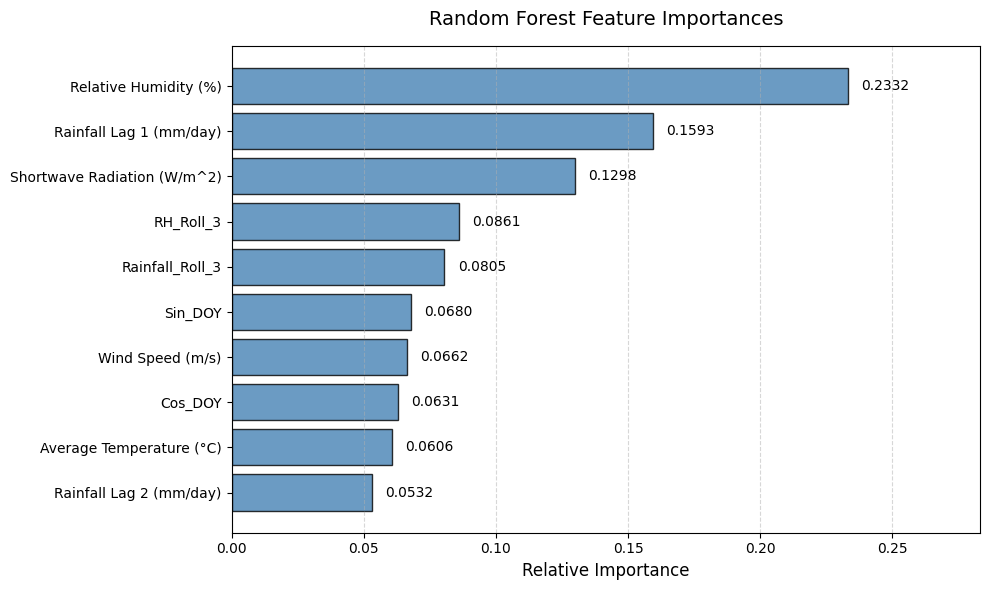

✓ Saved feature_importances.png


In [10]:
# ---- Feature Importance Plot ----
# Create a DataFrame for easier sorting
feat_imp_df = pd.DataFrame({
    'Feature': predictors,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True) # Sort ascending so the highest is at the top of the horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='black', alpha=0.8)

# Formatting
ax.set_xlabel('Relative Importance', fontsize=12)
ax.set_title('Random Forest Feature Importances', fontsize=14, pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Add the exact values at the end of each bar for readability
for index, value in enumerate(feat_imp_df['Importance']):
    ax.text(value + 0.005, index, f'{value:.4f}', va='center', fontsize=10)

# Expand x-axis limit slightly so the text doesn't get cut off
ax.set_xlim(0, feat_imp_df['Importance'].max() + 0.05)

plt.tight_layout()
plt.savefig("visualizations/feature_importances.png", dpi=200)
plt.show()
print("✓ Saved feature_importances.png")

---
## Step 7: Test Models Against Future Data & Comparative Plot

   FUTURE TESTING — Model vs GCM Simulated Precipitation


,Model,Future R²,Future RMSE (mm/day)
0,Random Forest,0.374823,5.311834


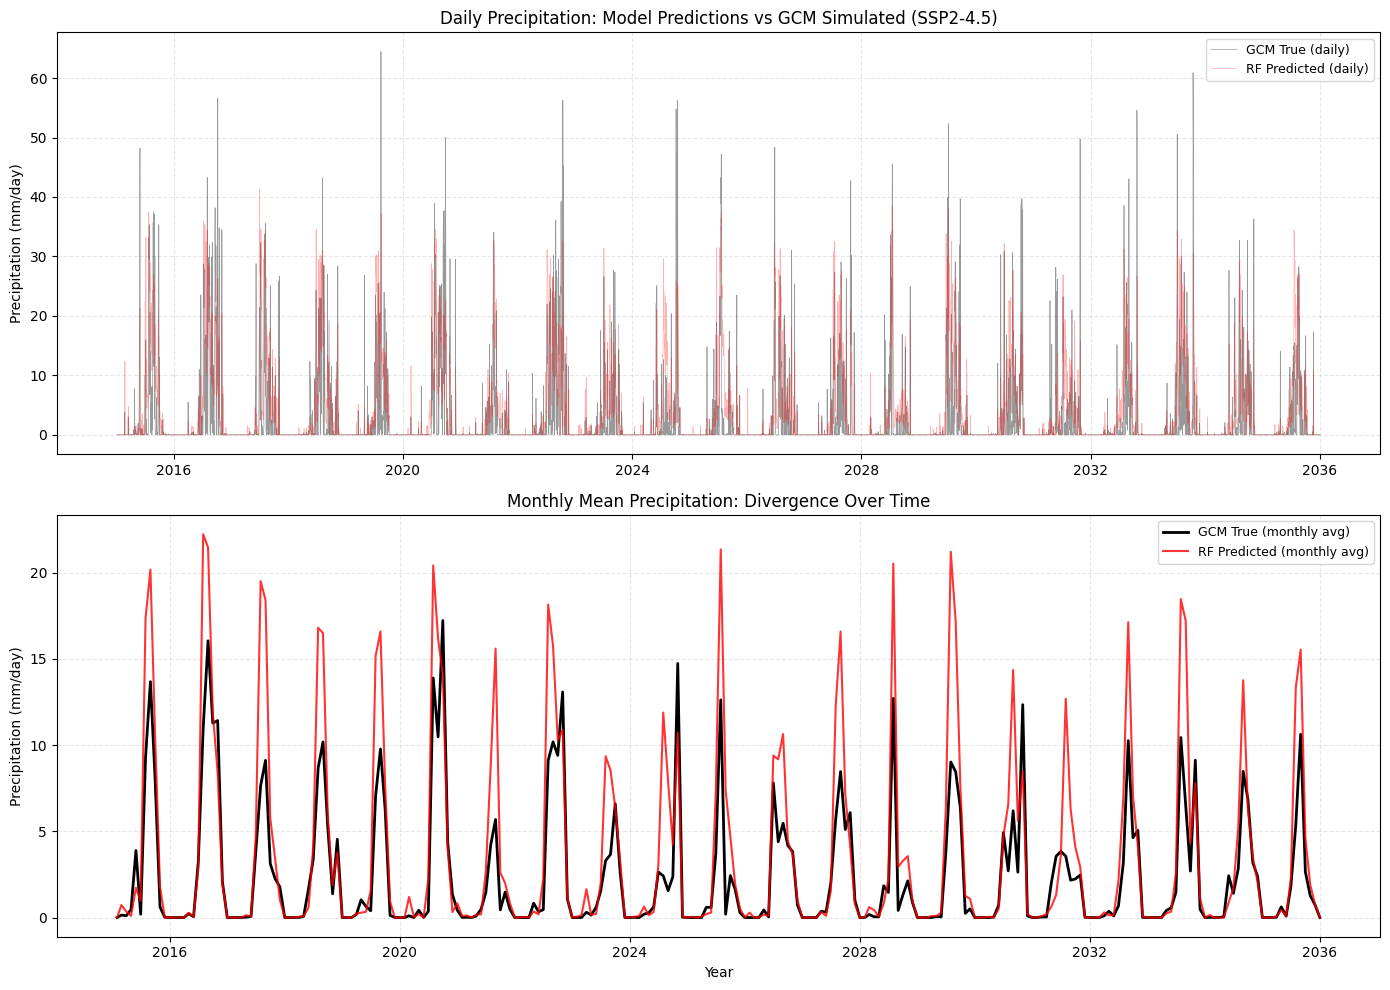

✓ Saved future_model_comparison.png


In [12]:
# 11)
# Load future CSV
future_df = pd.read_csv("future_data.csv")
future_df['time'] = pd.to_datetime(future_df['time'])
future_df.dropna(inplace=True)

X_future = future_df[predictors]
y_future_true = future_df[target]

# Scale using the SAME QuantileTransformer fitted on historical data
X_future_scaled = scaler.transform(X_future)

# Predict using Random Forest
rf_future = rf.predict(X_future_scaled)

# Apply Drizzle Threshold to Future Data
rf_future = np.where(rf_future < 1.0, 0, rf_future)

# ---- Future Accuracy Metrics ----
print("="*60)
print("   FUTURE TESTING — Model vs GCM Simulated Precipitation")
print("="*60)

rf_f_rmse = np.sqrt(mean_squared_error(y_future_true, rf_future))
rf_f_r2 = r2_score(y_future_true, rf_future)

future_summary = pd.DataFrame({
    'Model': ['Random Forest'],
    'Future R²': [rf_f_r2],
    'Future RMSE (mm/day)': [rf_f_rmse]
})
display(future_summary)

# ---- Yearly Moving Average for cleaner plot ----
result_df = pd.DataFrame({
    'time': future_df['time'],
    'GCM True': y_future_true.values,
    'RF Predicted': rf_future
}).set_index('time')

# Resample to monthly means for a cleaner trend view
# Changed 'ME' back to 'M' for compatibility with your pandas version
monthly = result_df.resample('M').mean() 

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Daily values (raw)
axes[0].plot(result_df.index, result_df['GCM True'], color='black', alpha=0.4, linewidth=0.5, label='GCM True (daily)')
axes[0].plot(result_df.index, result_df['RF Predicted'], color='red', alpha=0.3, linewidth=0.5, label='RF Predicted (daily)')
axes[0].set_title("Daily Precipitation: Model Predictions vs GCM Simulated (SSP2-4.5)", fontsize=12)
axes[0].set_ylabel("Precipitation (mm/day)")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot 2: Monthly means (trend)
axes[1].plot(monthly.index, monthly['GCM True'], color='black', linewidth=2, label='GCM True (monthly avg)')
axes[1].plot(monthly.index, monthly['RF Predicted'], color='red', linewidth=1.5, alpha=0.8, label='RF Predicted (monthly avg)')
axes[1].set_title("Monthly Mean Precipitation: Divergence Over Time", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Precipitation (mm/day)")
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("visualizations/future_model_comparison.png", dpi=200)
plt.show()
print("✓ Saved future_model_comparison.png")